In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\healthcare-dataset-stroke-data (1).csv")

In [3]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [6]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [7]:
def get_smoke_count(smoking_status):
    mask=df['smoking_status']==smoking_status
    return df[mask]

In [8]:
get_smoke_count('Unknown')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
23,64778,Male,82.0,0,1,Yes,Private,Rural,208.30,32.5,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5098,579,Male,9.0,0,0,No,children,Urban,71.88,17.5,Unknown,0
5101,36901,Female,45.0,0,0,Yes,Private,Urban,97.95,24.5,Unknown,0
5103,22127,Female,18.0,0,0,No,Private,Urban,82.85,46.9,Unknown,0
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0


In [9]:
df["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [10]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [11]:
null_values = df['bmi'].isnull().sum()
null_values

201

In [12]:
null_percentage = df['bmi'].isnull().mean()*100
null_percentage

3.9334637964774952

In [13]:
column_mean = df['bmi'].mean()
df['bmi'].fillna(column_mean, inplace=True)

In [14]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [15]:
columns = ['gender','ever_married','work_type', 'Residence_type','smoking_status']

for col in columns:
    unique_values = df[col].unique()
    print(f"Unique values for {col}:{unique_values}")

Unique values for gender:['Male' 'Female' 'Other']
Unique values for ever_married:['Yes' 'No']
Unique values for work_type:['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Unique values for Residence_type:['Urban' 'Rural']
Unique values for smoking_status:['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [16]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [17]:
# In gender column there is only one value for other so we replace it with male
df['gender'] = df['gender'].replace('Other', 'Male')

In [18]:
df['gender'].value_counts()

gender
Female    2994
Male      2116
Name: count, dtype: int64

In [19]:
mask1 = df[['gender','ever_married','work_type', 'Residence_type','smoking_status']].nunique()
mask1

gender            2
ever_married      2
work_type         5
Residence_type    2
smoking_status    4
dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


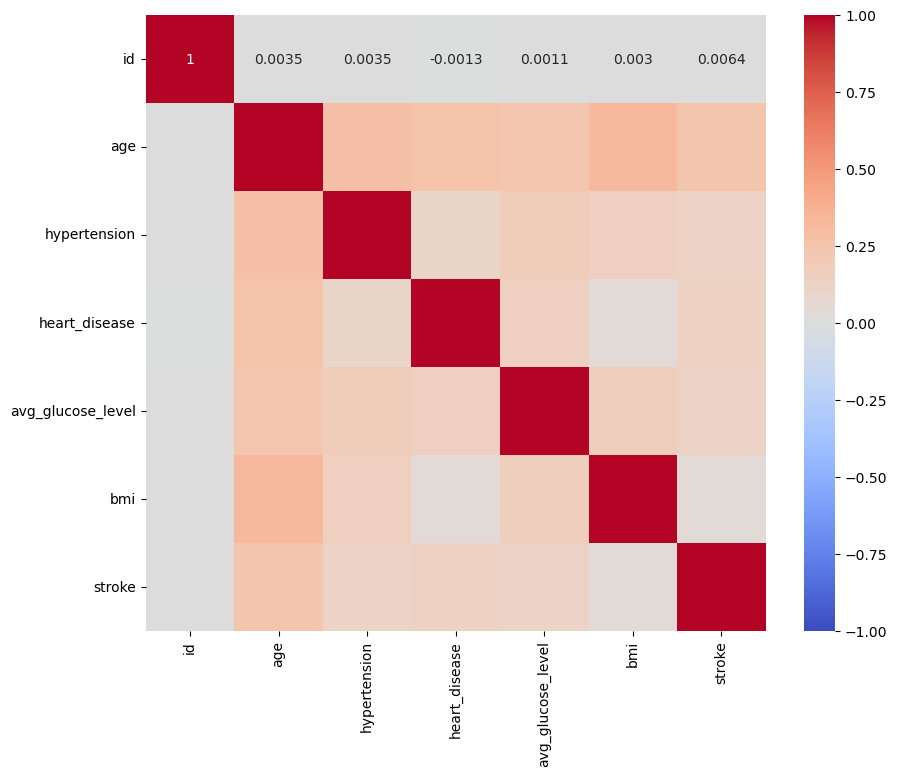

In [21]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)

plt.show()

# Feature Engineering

In [22]:
# Creating age group categories

print(f'maximum age variable: {df["age"].max()}')
print(f'minimum age variable: {df["age"].min()}')
print(f'Number of age variable: {df["age"].nunique()}')

maximum age variable: 82.0
minimum age variable: 0.08
Number of age variable: 104


In [23]:
# collapse age group categories
ranges = [0,13,18,45,60,100]
group_names = ['Children','Teens','Adults','Mid-adults','Elderly']
df['age_group'] = pd.cut(df['age'],bins=ranges,labels=group_names)
df['age_group'].unique()

['Elderly', 'Mid-adults', 'Adults', 'Children', 'Teens']
Categories (5, object): ['Children' < 'Teens' < 'Adults' < 'Mid-adults' < 'Elderly']

In [24]:
# For BMI

print(f'maximum age variable: {df["bmi"].max()}')
print(f'minimum age variable: {df["bmi"].min()}')
print(f'Number of age variable: {df["bmi"].nunique()}')

maximum age variable: 97.6
minimum age variable: 10.3
Number of age variable: 419


In [25]:
# collapse bmi into fewer groups

ranges = [0,19,25,30,100]
group_names = ['Underweight', 'Normal', 'Overweight', 'Obesity']
df['bmi_group'] = pd.cut(df['bmi'],bins=ranges,labels=group_names)
df['bmi_group'].unique()

['Obesity', 'Overweight', 'Normal', 'Underweight']
Categories (4, object): ['Underweight' < 'Normal' < 'Overweight' < 'Obesity']

In [26]:
# for avg glucose level

print(f'maximum age variable: {df["avg_glucose_level"].max()}')
print(f'minimum age variable: {df["avg_glucose_level"].min()}')
print(f'Number of age variable: {df["avg_glucose_level"].nunique()}')

maximum age variable: 271.74
minimum age variable: 55.12
Number of age variable: 3979


In [27]:
ranges = [0, 70, 99, 125, 280]
group_names = ['Low', 'Normal', 'High', 'Very_high']
df['avg_glucose_level_group'] = pd.cut(df['avg_glucose_level'],bins=ranges,labels=group_names)
df['avg_glucose_level_group'].unique()

['Very_high', 'High', 'Normal', 'Low']
Categories (4, object): ['Low' < 'Normal' < 'High' < 'Very_high']

# Exploratory data analysis(EDA)

In [34]:
df['stroke_label'] = df['stroke'].map({
    0: 'No Stroke',
    1: 'Stroke'
})

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


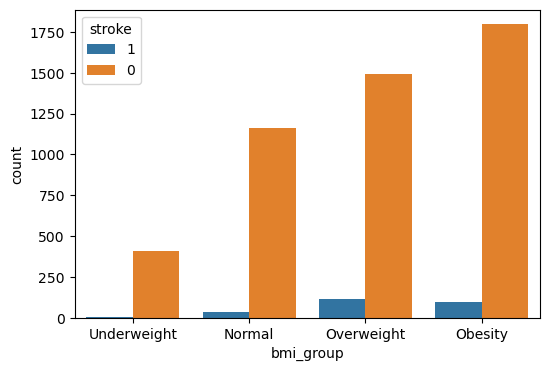

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='bmi_group', hue=df['stroke'].astype(str))
plt.show()

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


([<BarContainer object of 4 artists>, <BarContainer object of 4 artists>], ['Stroke', 'No Stroke'])


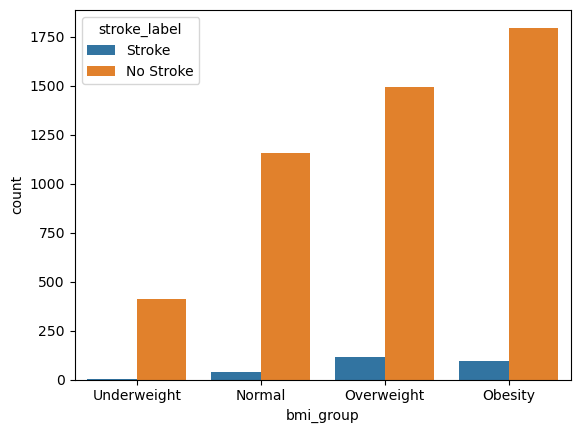

In [36]:
ax = sns.countplot(data=df, x='bmi_group', hue='stroke_label')
print(ax.get_legend_handles_labels())
plt.show()

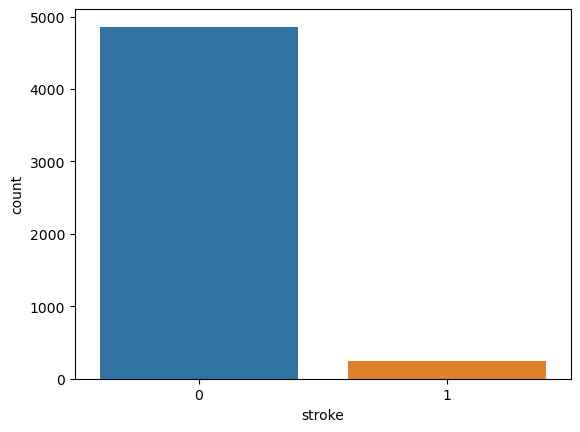

In [37]:
sns.countplot(x='stroke',data=df)
plt.show()

In [38]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,bmi_group,avg_glucose_level_group,stroke_label
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1,Elderly,Obesity,Very_high,Stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1,Elderly,Overweight,Very_high,Stroke
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1,Elderly,Obesity,High,Stroke
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1,Mid-adults,Obesity,Very_high,Stroke
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1,Elderly,Normal,Very_high,Stroke


In [34]:
#checking ki environment mein seaborn aur matplotlib versions ke beech compatibility issue toh nhi
import seaborn as sns
import matplotlib

print(sns.__version__)
print(matplotlib.__version__)

0.12.2
3.8.0


C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


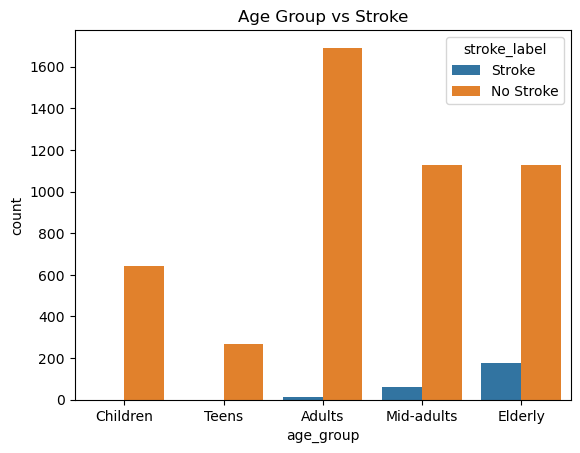

In [39]:
df['stroke_label'] = df['stroke'].map({0: 'No Stroke', 1: 'Stroke'})

sns.countplot(x='age_group', hue='stroke_label', data=df)
plt.title("Age Group vs Stroke")
plt.show()

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


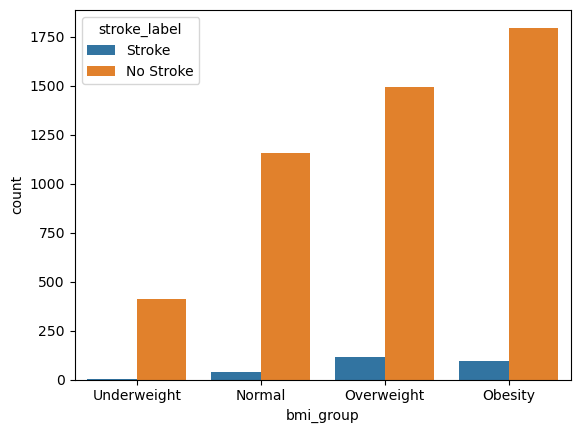

In [40]:
sns.countplot(x='bmi_group', hue='stroke_label', data=df)
plt.show()

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


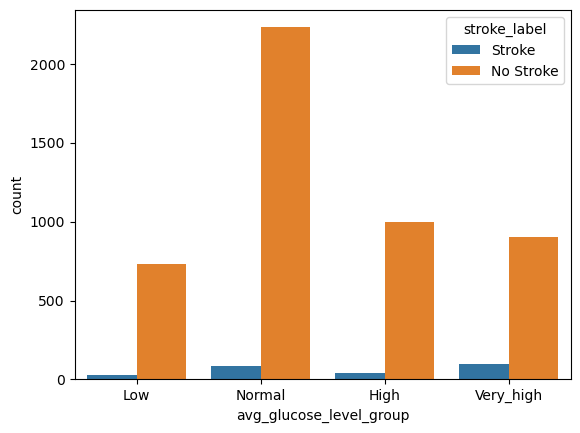

In [41]:
sns.countplot(x='avg_glucose_level_group',hue='stroke_label',data=df)
plt.show()

<Axes: xlabel='heart_disease', ylabel='age'>

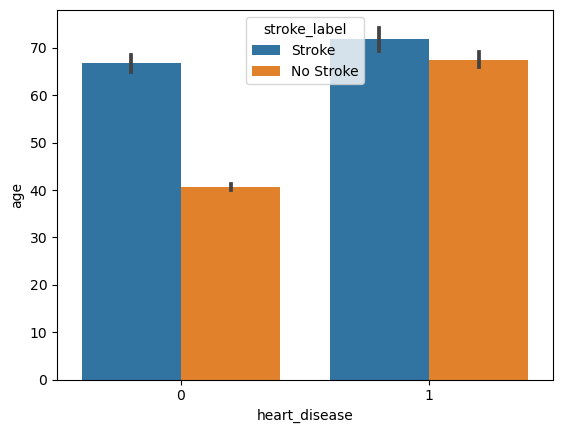

In [42]:
sns.barplot(x='heart_disease',y='age',data=df,hue='stroke_label')

In [43]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,bmi_group,avg_glucose_level_group,stroke_label
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1,Elderly,Obesity,Very_high,Stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1,Elderly,Overweight,Very_high,Stroke
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1,Elderly,Obesity,High,Stroke
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1,Mid-adults,Obesity,Very_high,Stroke
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1,Elderly,Normal,Very_high,Stroke
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.893237,never smoked,0,Elderly,Overweight,Normal,No Stroke
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.000000,never smoked,0,Elderly,Obesity,Very_high,No Stroke
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.600000,never smoked,0,Adults,Obesity,Normal,No Stroke
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.600000,formerly smoked,0,Mid-adults,Overweight,Very_high,No Stroke


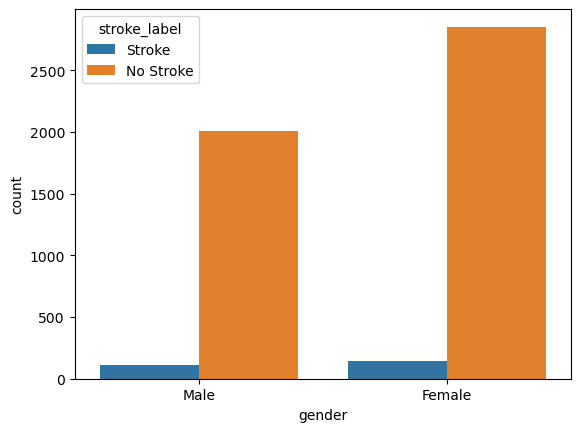

In [44]:
sns.countplot(x='gender',hue='stroke_label',data=df)
plt.show()

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


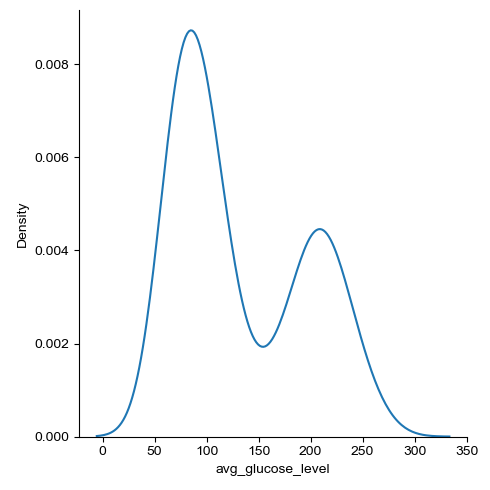

In [45]:
stroke = df[df['stroke']==1]
sns.displot(stroke['avg_glucose_level'], kind='kde')
sns.set_style('darkgrid')
plt.show()

C:\Users\Admin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


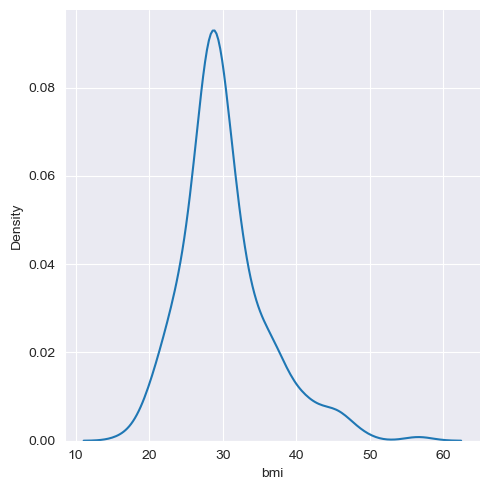

In [46]:
stroke = df[df['stroke']==1]
sns.displot(stroke['bmi'], kind='kde')
sns.set_style('darkgrid')
plt.show()

# Preprocessing

### Binary Encoding

In [47]:
#Instantiate LabelEncoder
labelencoder = LabelEncoder()

#Binary Encoding(encoding object columns with 2 unique values)
binary_cols =  ['ever_married', 'Residence_type', 'gender']
for col in binary_cols:
    df[col]=labelencoder.fit_transform(df[col])

### Label Encoding

In [48]:
categorical_cols = ['age_group', 'bmi_group', 'avg_glucose_level_group']

label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

## One hot encoding

In [49]:
#Encode object columns that more than 2 unique values
df = pd.get_dummies(df, columns=['work_type', 'smoking_status'], drop_first=True)

In [50]:
df

,id,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,...,bmi_group,avg_glucose_level_group,stroke_label,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,1,67.0,0,1,1,1,228.69,36.600000,1,...,1,3,Stroke,False,True,False,False,True,False,False
1,51676,0,61.0,0,0,1,0,202.21,28.893237,1,...,2,3,Stroke,False,False,True,False,False,True,False
2,31112,1,80.0,0,1,1,0,105.92,32.500000,1,...,1,0,Stroke,False,True,False,False,False,True,False
3,60182,0,49.0,0,0,1,1,171.23,34.400000,1,...,1,3,Stroke,False,True,False,False,False,False,True
4,1665,0,79.0,1,0,1,0,174.12,24.000000,1,...,0,3,Stroke,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,1,83.75,28.893237,0,...,2,2,No Stroke,False,True,False,False,False,True,False
5106,44873,0,81.0,0,0,1,1,125.20,40.000000,0,...,1,3,No Stroke,False,False,True,False,False,True,False
5107,19723,0,35.0,0,0,1,0,82.99,30.600000,0,...,1,2,No Stroke,False,False,True,False,False,True,False
5108,37544,1,51.0,0,0,1,0,166.29,25.600000,0,...,2,3,No Stroke,False,True,False,False,True,False,False


In [51]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [52]:
df['stroke'].value_counts(normalize=True) * 100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

#### It looks like our data is imbalanced, so we have to resample it.

In [53]:
# handle Imbalance data
stroke_0=df[df['stroke']==0]
stroke_1=df[df['stroke']==1]

In [54]:
# resample
from sklearn.utils import resample
df_upsampled=resample(stroke_1,replace=True,n_samples=4700)

In [55]:
new_df=pd.concat([stroke_0,df_upsampled])
from sklearn.utils import shuffle
new_df=shuffle(new_df)

In [56]:
new_df['stroke'].value_counts()

stroke
0    4861
1    4700
Name: count, dtype: int64

In [61]:
X = new_df.drop(columns=['id', 'stroke', 'stroke_label'])
y = new_df['stroke']

In [62]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6692, 18)
(2869, 18)
(6692,)
(2869,)


In [63]:
from sklearn.preprocessing import MinMaxScaler

Scaler = MinMaxScaler()
# fit the scaler to the train set, it will learn parameters
Scaler.fit(X_train)

#transform train and test set

X_train_scaled = Scaler.transform(X_train)
X_test_scaled = Scaler.transform(X_test)

### Now lets compare accuracy using Different Algorithms

# 1) Logistic Regression

In [64]:
logistic_reg = LogisticRegression()

In [65]:
logistic_reg.fit(X_train, y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [66]:
y_pred = logistic_reg.predict(X_test)

In [67]:
log_reg_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {log_reg_accuracy}")

Accuracy: 0.766120599512025


#### lets evaluate Accuracy of  model

In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.73      0.76      1478
           1       0.74      0.81      0.77      1391

    accuracy                           0.77      2869
   macro avg       0.77      0.77      0.77      2869
weighted avg       0.77      0.77      0.77      2869



#### sample explaination
![](https://i.stack.imgur.com/Wsz2t.png)

# 2) Decision Tree

In [69]:
# Create the Decision Tree Classifier
decision_tree_classifier = DecisionTreeClassifier()

In [70]:
# Train the classifier on the training data
decision_tree_classifier.fit(X_train, y_train)

DecisionTreeClassifier()

In [71]:
# Make predictions on the test set
y_pred = decision_tree_classifier.predict(X_test)

In [72]:
# Calculate the accuracy of the classifier
dt_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {dt_accuracy}")



Accuracy: 0.9703729522481701


# Visualization Of  Decision Tree

In [73]:
from sklearn.tree import plot_tree, export_text

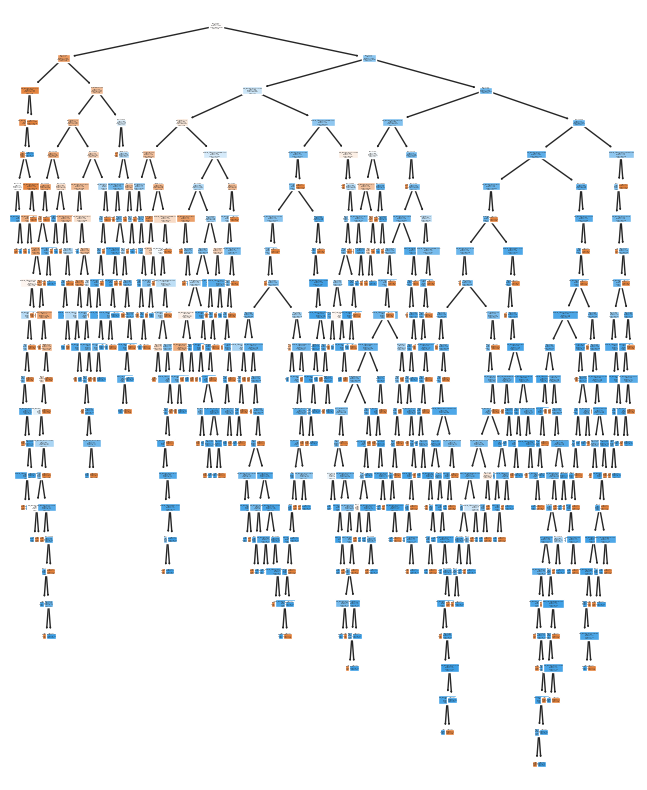

In [74]:
plt.figure(figsize=(8,10))
plot_tree(decision_tree_classifier, feature_names=X.columns,class_names=True, filled=True);

#### lets evaluate Accuracy of model

In [75]:
predictions = decision_tree_classifier.predict(X_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1478
           1       0.94      1.00      0.97      1391

    accuracy                           0.97      2869
   macro avg       0.97      0.97      0.97      2869
weighted avg       0.97      0.97      0.97      2869



# 3) Random forest Classifier

In [76]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {rf_accuracy}")

Accuracy: 0.9891948414081562


# Visualization Of Random Forest

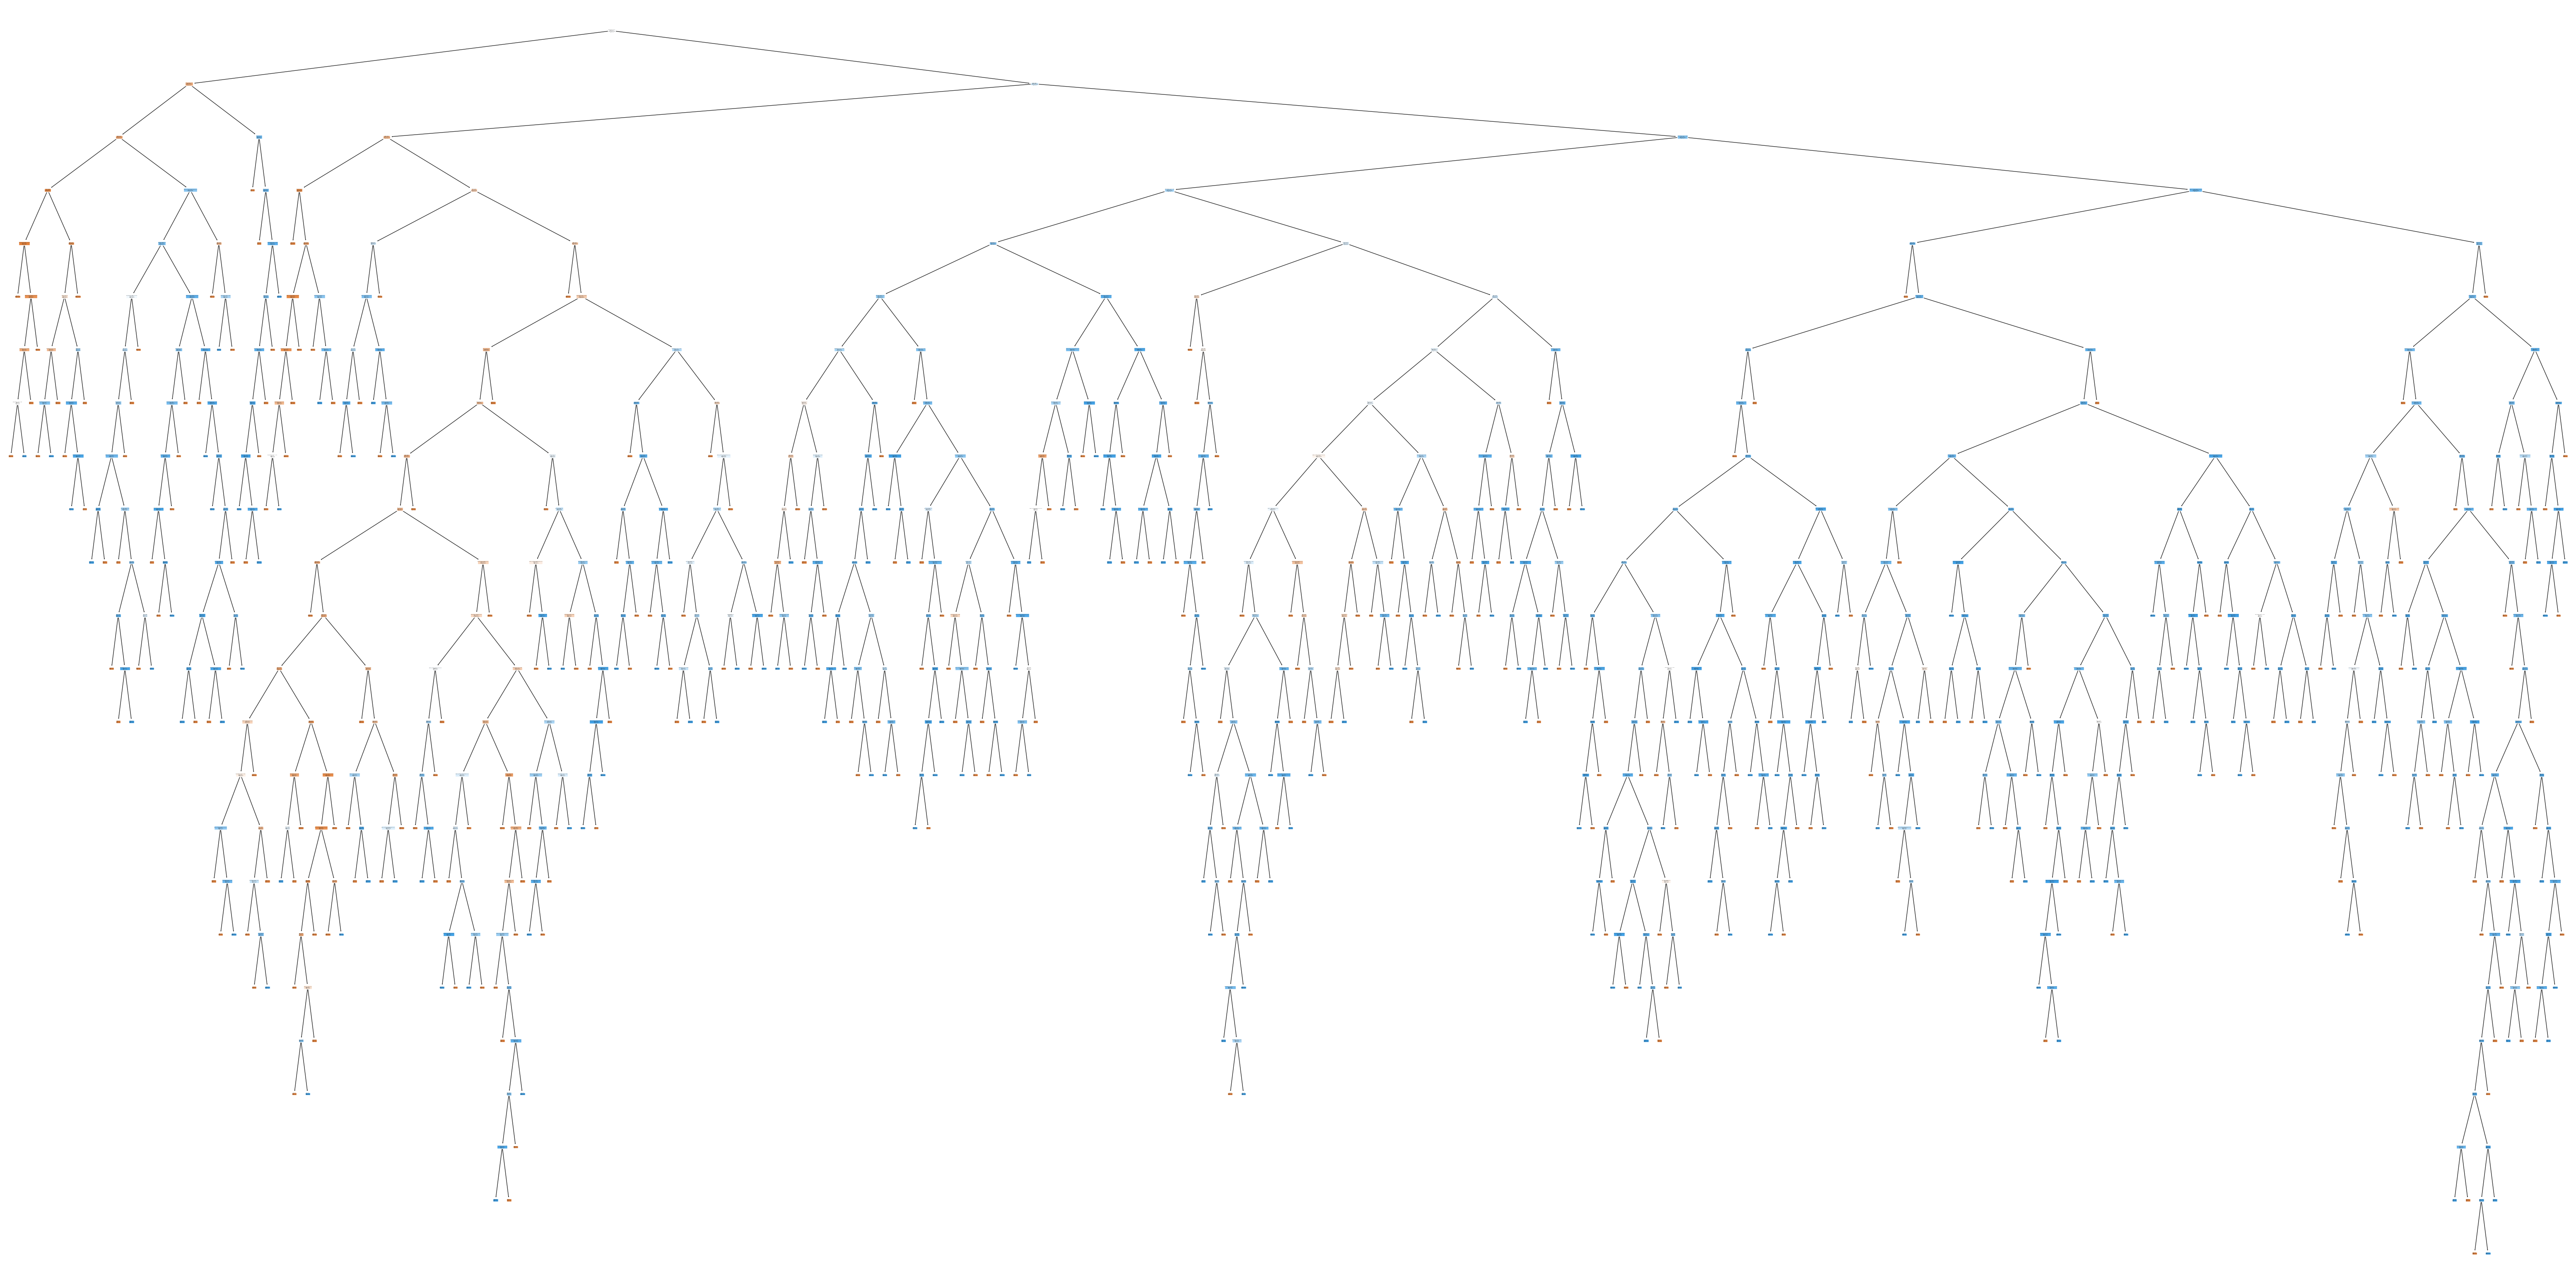

In [77]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(rf_classifier.estimators_[0], feature_names = X.columns,class_names=True,filled=True);

##### lets evaluate Accuracy of model

In [78]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[1447   31]
 [   0 1391]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1478
           1       0.98      1.00      0.99      1391

    accuracy                           0.99      2869
   macro avg       0.99      0.99      0.99      2869
weighted avg       0.99      0.99      0.99      2869



## Hyperparameter Tunning By GridSearchCV Method.

In [79]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

In [80]:
params = {
    'max_depth': [2,3,5,10,20],
    'min_samples_leaf': [5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}

In [81]:
from sklearn.model_selection import GridSearchCV

In [82]:
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 5,
                           n_jobs=-1, scoring="f1_weighted")

In [83]:

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='f1_weighted')

In [84]:
grid_search.best_score_

0.941102509446428

In [85]:
grid_search.cv_results_ 

{'mean_fit_time': array([0.07732563, 0.15352864, 0.16736588, 0.23657775, 0.61423893,
        2.24169073, 0.16857238, 0.52208729, 0.4762217 , 0.65477347,
        1.12431326, 2.53614006, 0.17518134, 0.51788864, 0.4998045 ,
        0.57460837, 1.07549081, 2.21051693, 0.17691054, 0.44545097,
        0.45132914, 0.58205423, 1.05395017, 2.22782078, 0.16741118,
        0.45689611, 0.43086119, 0.55909882, 1.0650177 , 2.21325459,
        0.1906477 , 0.47225366, 0.43200178, 0.54767408, 1.06251817,
        2.37086978, 0.18726764, 0.53939209, 0.50319262, 0.67514901,
        1.34276972, 2.68432403, 0.2475142 , 0.54677544, 0.49904327,
        0.72414083, 1.24444852, 2.53270807, 0.23018284, 0.46599603,
        0.4750596 , 0.6811769 , 1.19459324, 2.4978209 , 0.19719839,
        0.47143383, 0.46433969, 0.62903728, 1.16839752, 2.43542008,
        0.19894328, 0.56112175, 0.42761989, 0.57252226, 1.19055562,
        2.49481096, 0.22155433, 0.52082896, 0.49640713, 0.61713519,
        1.16322985, 2.42923737,

In [86]:
rf_best = grid_search.best_estimator_
rf_best

RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=200,
                       n_jobs=-1, random_state=42)

In [87]:
rf_best.score(X_train,y_train)

0.9728033472803347

In [88]:
rf_best.score(X_test,y_test)

0.9466713140467061

In [89]:
yhat = rf_best.predict(X_test)

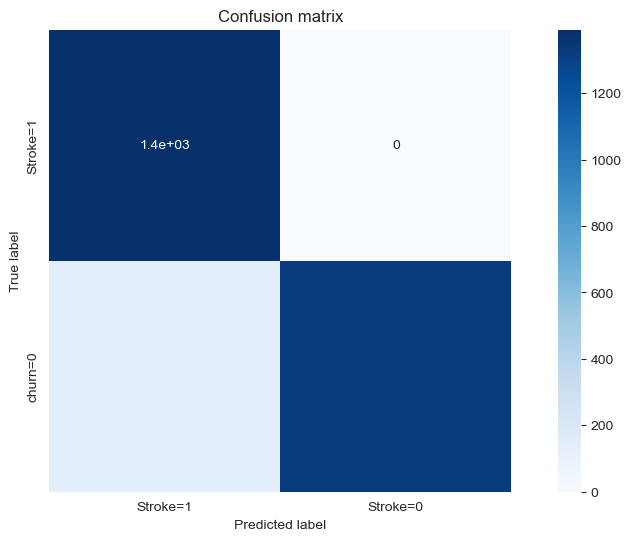

In [90]:
cnf_matrix = confusion_matrix(y_test, yhat, labels=[1,0])
plt.figure(figsize=(12,6))
sns.heatmap(cnf_matrix, annot=True, xticklabels=['Stroke=1','Stroke=0'],yticklabels=['Stroke=1','churn=0'], cmap='Blues', square=True);
plt.xlabel('Predicted label');
plt.ylabel('True label');
plt.title('Confusion matrix');

In [98]:
print(confusion_matrix(y_test,yhat))
print(classification_report(y_test,yhat))

[[1325  153]
 [   0 1391]]
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      1478
           1       0.90      1.00      0.95      1391

    accuracy                           0.95      2869
   macro avg       0.95      0.95      0.95      2869
weighted avg       0.95      0.95      0.95      2869



# Final Accuracy

In [99]:
from sklearn.metrics import accuracy_score

print("Accuracy :", accuracy_score(y_test, yhat))

Accuracy : 0.9466713140467061


# Conclusion

This project successfully developed a Stroke Prediction model using the Random Forest algorithm.
The dataset was cleaned, analyzed, and preprocessed through feature engineering, resampling, encoding, train-test splitting, and feature scaling.
The trained model achieved approximately 95% accuracy and showed good performance based on the confusion matrix and classification report. 
